# Bonus: Laboratorio de Experimentos

Este notebook implementa un sistema de ejecucion automatica de experimentos
(ExperimentRunner) que combina GridSearchCV + cross-validation para entrenar,
optimizar y comparar multiples configuraciones de modelos de forma reproducible.

El runner recibe un pipeline, un grid de hiperparametros y los splits train/test,
y devuelve un dict de metricas (train y test) junto con el mejor CV score.
Permite:
  - Automatizar experimentos (no hay que entrenar a mano cada combinacion).
  - Comparar sistematicamente modelos en una tabla.
  - Detectar overfitting via el gap train-test.
  - Guardar resultados en JSON para reproducibilidad.

Se aplica sobre los problemas de las misiones 2 (entregas, regresion) y
3 (sentimiento, clasificacion) del challenge.

In [1]:
# pandas, numpy, matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# time: cronometrar
import time
# json: persistir resultados
import json
# re: limpieza de texto
import re
# Path: rutas
from pathlib import Path
# datetime: marcas de tiempo (disponible)
from datetime import datetime

# Pipeline
from sklearn.pipeline import Pipeline
# StandardScaler
from sklearn.preprocessing import StandardScaler
# train_test_split y GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV
# metricas de regresion y clasificacion
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score

# modelos de regresion
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
# ComplementNB
from sklearn.naive_bayes import ComplementNB
# LinearSVC
from sklearn.svm import LinearSVC

# Silenciar warnings
import warnings
warnings.filterwarnings('ignore')
# Estilo de graficos
plt.style.use('seaborn-v0_8-whitegrid')

# data_raw: ruta
data_raw = Path("..") / "data" / "raw"

## El motor ExperimentRunner

Abstrae el ciclo completo de un experimento: GridSearchCV sobre un pipeline,
evaluacion en train y test, registro de metricas y guardado en JSON.

In [2]:
# Clase que automatiza experimentos de ML
class ExperimentRunner:
# Docstring de la clase
    """Automatiza experimentos de ML con GridSearchCV + cross-validation."""

# Init: prepara la lista de experimentos
    def __init__(self):
# Cada experimento es un dict de metricas
        self.experiments = []

# run(): ejecuta un experimento completo
    def run(self, name, pipeline, param_grid, X_train, y_train,
# Parametros: nombre, pipeline, grid y splits; task elige metrica
            X_test, y_test, task='regression', cv=5):
# Docstring del metodo
        """
        Ejecuta un experimento completo.
        task: 'regression' o 'classification'
        """
# Cabecera visual del experimento
        print(f'\n{"="*60}')
# Nombre del experimento
        print(f'EXPERIMENTO: {name}')
        print(f'{"="*60}')

# scoring: MAE para regresion, accuracy para clasificacion
        scoring = 'neg_mean_absolute_error' if task == 'regression' else 'accuracy'
# Cronometro
        start = time.time()

# GridSearchCV: busca los mejores hiperparametros
        grid = GridSearchCV(
# pipeline + grid + scoring
            pipeline, param_grid, cv=cv, scoring=scoring,
# paralelo, refit al mejor modelo
            n_jobs=-1, refit=True, verbose=0
        )
# Entrena en train
        grid.fit(X_train, y_train)
# Tiempo transcurrido
        elapsed = time.time() - start

# Prediccion en train
        y_pred_train = grid.predict(X_train)
# Prediccion en test
        y_pred_test = grid.predict(X_test)

# Ramas segun tipo de tarea
        if task == 'regression':
# Dict de metricas de regresion
            experiment = {
                'name': name,
                'task': task,
# Mejores hiperparametros encontrados
                'best_params': grid.best_params_,
# mejor CV score (negativo -> MAE)
                'best_cv_score': -grid.best_score_,
# MAE en train
                'MAE_train': mean_absolute_error(y_train, y_pred_train),
# MAE en test
                'MAE_test': mean_absolute_error(y_test, y_pred_test),
# R2 en train
                'R2_train': r2_score(y_train, y_pred_train),
# R2 en test
                'R2_test': r2_score(y_test, y_pred_test),
# Brecha train-test (overfitting)
                'gap_R2': r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
# Tiempo
                'time': round(elapsed, 2),
            }
# Ramas para clasificacion
        else:
# Dict de metricas de clasificacion
            experiment = {
                'name': name,
                'task': task,
# Mejores hiperparametros
                'best_params': grid.best_params_,
# Mejor CV score
                'best_cv_score': grid.best_score_,
# Accuracy en train
                'acc_train': accuracy_score(y_train, y_pred_train),
# Accuracy en test
                'acc_test': accuracy_score(y_test, y_pred_test),
# F1 clase negativa en train
                'f1_train': f1_score(y_train, y_pred_train, pos_label='negativo'),
# F1 clase negativa en test
                'f1_test': f1_score(y_test, y_pred_test, pos_label='negativo'),
# Brecha de accuracy (overfitting)
                'gap_acc': accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test),
# Tiempo
                'time': round(elapsed, 2),
            }

# Registra el experimento
        self.experiments.append(experiment)

# Resumen impreso
        print(f'Mejores params: {experiment["best_params"]}')
        print(f'CV Score:       {experiment["best_cv_score"]:.4f}')
        if task == 'regression':
# Rama regresion
            print(f'MAE Test:       {experiment["MAE_test"]:.3f}')
            print(f'R2 Test:        {experiment["R2_test"]:.3f}')
        else:
# Rama clasificacion
            print(f'Acc Test:       {experiment["acc_test"]:.3f}')
            print(f'F1(neg) Test:   {experiment["f1_test"]:.3f}')
        print(f'Tiempo:         {experiment["time"]}s')

        return experiment
# Retorna el dict

    def comparison_table(self):
# comparison_table(): tabla comparativa
        """Genera una tabla comparativa de todos los experimentos registrados."""
# Docstring
        df = pd.DataFrame(self.experiments)
# DataFrame con todos los experimentos
        cols = ['name', 'task', 'best_cv_score']
# Columnas base
        if 'MAE_test' in df.columns:
# Si hubo regresion, agrega columnas MAE/R2
            cols += ['MAE_train', 'MAE_test', 'R2_train', 'R2_test', 'gap_R2']
        if 'acc_test' in df.columns:
# Si hubo clasificacion, agrega columnas acc/f1
            cols += ['acc_train', 'acc_test', 'f1_test', 'gap_acc']
        cols += ['time']
# Siempre agrega el tiempo
        return df[cols]
# Retorna la tabla ordenada

    def betrayed_models(self):
# betrayed_models(): detecta overfitting claro
        """Identifica modelos con overfitting claro (gap train-test alto)."""
# Docstring
        print('\n' + '='*60)
# Titulo llamativo
        print('MODELOS QUE PARECIAN PROMETEDORES PERO ME TRAICIONARON')
# Mensaje de alerta
        print('='*60)
        found = False
# Bandera: existe al menos un traidor?
        for e in self.experiments:
# Recorre experimentos
            if e['task'] == 'regression' and e['gap_R2'] > 0.15:
# Regresion con gap de R2 alto
                found = True
                print(f'\n{e["name"]}:')
# Imprime nombre
                print(f'  R2 Train: {e["R2_train"]:.3f} (perfecto en train)')
                print(f'  R2 Test:  {e["R2_test"]:.3f} (cae en test)')
                print(f'  Gap:      {e["gap_R2"]:.3f} -> OVERFITTING')
                print(f'  Contraataque: reducir max_depth / n_estimators, o aumentar min_samples_leaf')
# Sugerencia para mitigar el overfitting
            elif e['task'] == 'classification' and e['gap_acc'] > 0.15:
# Clasificacion con gap de acc alto
                found = True
                print(f'\n{e["name"]}:')
                print(f'  Acc Train: {e["acc_train"]:.3f}')
                print(f'  Acc Test:  {e["acc_test"]:.3f}')
                print(f'  Gap:       {e["gap_acc"]:.3f} -> OVERFITTING')
# Si no hay ninguno
        if not found:
            print('\nNingun modelo presento overfitting severo (gap > 0.15).')

# save(): persiste resultados en JSON
    def save(self, path='outputs/experiment_results.json'):
# Docstring
        """Guarda los resultados de todos los experimentos en JSON."""
# Abre archivo de escritura
        with open(path, 'w') as f:
# Guarda la lista de experimentos
            json.dump(self.experiments, f, indent=2, default=str)
# Confirma la ruta
        print(f'\nResultados guardados en {path}')

## Datos de regresion (mision 2)

Reproducir el feature engineering del notebook 02_plazo_entrega para tener un dataset
listo para regresion.

In [3]:
# Reproduce el feature engineering de la mision 2
orders = pd.read_csv(data_raw / "olist_orders_dataset.csv")
order_items = pd.read_csv(data_raw / "olist_order_items_dataset.csv")
products = pd.read_csv(data_raw / "olist_products_dataset.csv")
customers = pd.read_csv(data_raw / "olist_customers_dataset.csv")
payments = pd.read_csv(data_raw / "olist_order_payments_dataset.csv")

# Fechas a datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
# delivery_days: dias reales de entrega
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
# estimated_days: promesa en dias
orders['estimated_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days

# Solo pedidos entregados
entregados = orders[(orders['order_status'] == 'delivered') &
                    (orders['delivery_days'] > 0) &
                    (orders['delivery_days'] <= 70)].copy()
# Caracteristicas temporales
entregados['purchase_month'] = entregados['order_purchase_timestamp'].dt.month
entregados['purchase_dow'] = entregados['order_purchase_timestamp'].dt.dayofweek

# Merge items con productos
items = order_items.merge(
    products[['product_id', 'product_weight_g']], on='product_id'
)
# Agregacion por pedido
items_agg = items.groupby('order_id').agg({
    'price': 'sum', 'freight_value': 'sum', 'product_weight_g': 'sum',
    'order_item_id': 'count'
}).reset_index()
# Renombra agregados
items_agg.columns = ['order_id', 'precio_total', 'flete_total', 'peso_total_g', 'n_items']

# Cuotas por pedido
pay_agg = payments.groupby('order_id')['payment_installments'].sum().reset_index()

# Une todo en una sola tabla
m2_data = entregados.merge(items_agg, on='order_id')\
    .merge(pay_agg, on='order_id', how='left')\
    .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
# Cuotas nulas a 0
m2_data['installments'] = m2_data['payment_installments'].fillna(0)

# Codifica estado del cliente
from sklearn.preprocessing import LabelEncoder
le_state = LabelEncoder()
m2_data['customer_state_enc'] = le_state.fit_transform(m2_data['customer_state'].fillna('XX'))

# Features del modelo de regresion
features_reg = ['precio_total', 'flete_total', 'peso_total_g', 'n_items',
                'purchase_month', 'purchase_dow', 'estimated_days',
                'installments', 'customer_state_enc']

# X e y
X_r = m2_data[features_reg]
y_r = m2_data['delivery_days']

# Split 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
# Aviso de dataset listo
print(f'Regresion listo: train={X_train_r.shape[0]}, test={X_test_r.shape[0]}')

Regresion listo: train=77035, test=19259


## Datos de texto (mision 3)

Reproducir el preprocesamiento de texto del notebook 03_opiniones_reviews.

In [4]:
# stemmer y stopwords
from nltk.stem import RSLPStemmer
from nltk.corpus import stopwords

# carga reviews
reviews = pd.read_csv(data_raw / "olist_order_reviews_dataset.csv")
# solo columnas utiles
rt = reviews[['review_score', 'review_comment_message']].copy()
# descarta sin texto
rt = rt.dropna(subset=['review_comment_message'])
# descarta vacios
rt = rt[rt['review_comment_message'].str.strip() != '']
# descarta 3 estrellas
rt = rt[rt['review_score'] != 3]
# binariza sentimiento
rt['sentiment'] = np.where(rt['review_score'] >= 4, 'positivo', 'negativo')

# stopwords portugues
stop_pt = set(stopwords.words('portuguese'))
# negaciones conservadas
negaciones = {'nao', 'não', 'nem', 'nunca', 'jamais', 'nenhum', 'nenhuma', 'tampouco'}
# resta negaciones
stop_ok = stop_pt - negaciones
# stemmer
stemmer = RSLPStemmer()

# funcion de limpieza
def limpiar(texto):
# minusculas
    t = str(texto).lower()
# quita urls y saltos
    t = re.sub(r'http\S+|\n', ' ', t)
# conserva letras
    t = re.sub(r'[^a-zà-ÿ]', ' ', t)
# filtra stopwords y aplica stemming
    p = [stemmer.stem(w) for w in t.split() if w not in stop_ok and len(w) > 2]
# junta en una lista
    return ' '.join(p)

# aplica limpieza
rt['texto_limpio'] = rt['review_comment_message'].apply(limpiar)
# descarta vacios
rt = rt[rt['texto_limpio'].str.len() > 0]

# X e y
X_c = rt['texto_limpio']
y_c = rt['sentiment']

# split estratificado
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)
# aviso de dataset listo
print(f'Clasificacion listo: train={len(X_train_c)}, test={len(X_test_c)}')

Clasificacion listo: train=29645, test=7412


## Ronda 1: modelos de regresion

GridSearch sobre Decision Tree, Random Forest y Gradient Boosting.

In [5]:
# Instancia el runner
runner = ExperimentRunner()

# Experimento 1: Decision Tree
runner.run(
    name='Decision Tree (GridSearch)',
# pipeline escalar + arbol
    pipeline=Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
# grid de hiperparametros del arbol
    param_grid={
# profundidad maxima
        'model__max_depth': [5, 10, 15, None],
# minimo para dividir
        'model__min_samples_split': [2, 5],
# minimo por hoja
        'model__min_samples_leaf': [1, 5]
    },
# datos de regresion
    X_train=X_train_r, y_train=y_train_r,
    X_test=X_test_r, y_test=y_test_r,
# tarea: regression
    task='regression'
)


EXPERIMENTO: Decision Tree (GridSearch)


Mejores params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
CV Score:       4.8734
MAE Test:       4.808
R2 Test:        0.326
Tiempo:         10.17s


{'name': 'Decision Tree (GridSearch)',
 'task': 'regression',
 'best_params': {'model__max_depth': 10,
  'model__min_samples_leaf': 5,
  'model__min_samples_split': 2},
 'best_cv_score': np.float64(4.8733831913706185),
 'MAE_train': 4.638524027725402,
 'MAE_test': 4.808147169747465,
 'R2_train': 0.37498767417957024,
 'R2_test': 0.3256853646975203,
 'gap_R2': 0.049302309482049944,
 'time': 10.17}

In [6]:
# Experimento 2: Random Forest
runner.run(
    name='Random Forest (GridSearch)',
# pipeline escalar + RF
    pipeline=Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=42))
    ]),
# grid de hiperparametros del bosque
    param_grid={
# cantidad de arboles
        'model__n_estimators': [50, 100],
# profundidad
        'model__max_depth': [10, 20, None],
# minimo para dividir
        'model__min_samples_split': [2, 5]
    },
# datos de regresion
    X_train=X_train_r, y_train=y_train_r,
    X_test=X_test_r, y_test=y_test_r,
# tarea: regression
    task='regression'
)


EXPERIMENTO: Random Forest (GridSearch)


Mejores params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
CV Score:       4.7538
MAE Test:       4.715
R2 Test:        0.352
Tiempo:         325.45s


{'name': 'Random Forest (GridSearch)',
 'task': 'regression',
 'best_params': {'model__max_depth': 10,
  'model__min_samples_split': 2,
  'model__n_estimators': 100},
 'best_cv_score': np.float64(4.753801605365327),
 'MAE_train': 4.549168451955446,
 'MAE_test': 4.715325479300736,
 'R2_train': 0.4061275483948572,
 'R2_test': 0.3520308747805667,
 'gap_R2': 0.05409667361429049,
 'time': 325.45}

In [7]:
# Experimento 3: Gradient Boosting
runner.run(
    name='Gradient Boosting (GridSearch)',
# pipeline escalar + GB
    pipeline=Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
# grid de hiperparametros de GB
    param_grid={
# arboles
        'model__n_estimators': [50, 100],
# learning_rate (velocidad de aprendizaje)
        'model__learning_rate': [0.05, 0.1],
# profundidad
        'model__max_depth': [3, 5]
    },
# datos de regresion
    X_train=X_train_r, y_train=y_train_r,
    X_test=X_test_r, y_test=y_test_r,
# tarea: regression
    task='regression'
)


EXPERIMENTO: Gradient Boosting (GridSearch)


Mejores params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}
CV Score:       4.7066
MAE Test:       4.673
R2 Test:        0.360
Tiempo:         93.75s


{'name': 'Gradient Boosting (GridSearch)',
 'task': 'regression',
 'best_params': {'model__learning_rate': 0.1,
  'model__max_depth': 5,
  'model__n_estimators': 100},
 'best_cv_score': np.float64(4.706645362413755),
 'MAE_train': 4.609548630514856,
 'MAE_test': 4.67276449640413,
 'R2_train': 0.3834115845913194,
 'R2_test': 0.36012868214163996,
 'gap_R2': 0.023282902449679455,
 'time': 93.75}

## Ronda 2: modelos de texto

GridSearch sobre TF-IDF + ComplementNB, y TF-IDF + LinearSVC.

In [8]:
# Experimento 4: ComplementNB + TF-IDF
runner.run(
    name='ComplementNB + TF-IDF (GridSearch)',
# pipeline vectorizador + NB
    pipeline=Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', ComplementNB())
    ]),
# grid de hiperparametros
    param_grid={
# max features del vectorizador
        'tfidf__max_features': [3000, 5000],
# min_df (documentos minimos)
        'tfidf__min_df': [2, 3],
# suavizado alfa de NB
        'clf__alpha': [0.1, 0.5, 1.0]
    },
# datos de texto
    X_train=X_train_c, y_train=y_train_c,
    X_test=X_test_c, y_test=y_test_c,
# tarea: classification
    task='classification'
)


EXPERIMENTO: ComplementNB + TF-IDF (GridSearch)


Mejores params: {'clf__alpha': 1.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 2}
CV Score:       0.9004
Acc Test:       0.897
F1(neg) Test:   0.843
Tiempo:         9.14s


{'name': 'ComplementNB + TF-IDF (GridSearch)',
 'task': 'classification',
 'best_params': {'clf__alpha': 1.0,
  'tfidf__max_features': 3000,
  'tfidf__min_df': 2},
 'best_cv_score': np.float64(0.9003541912632821),
 'acc_train': 0.9065272389947715,
 'acc_test': 0.8974635725849973,
 'f1_train': 0.8567144112932417,
 'f1_test': 0.84251968503937,
 'gap_acc': 0.009063666409774185,
 'time': 9.14}

In [9]:
# Experimento 5: LinearSVC + TF-IDF
runner.run(
    name='LinearSVC + TF-IDF (GridSearch)',
# pipeline vectorizador + SVM
    pipeline=Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LinearSVC(random_state=42))
    ]),
# grid de hiperparametros
    param_grid={
# max features
        'tfidf__max_features': [3000, 5000],
# min_df
        'tfidf__min_df': [2, 3],
# C: regularizacion de SVM
        'clf__C': [0.1, 1.0]
    },
# datos de texto
    X_train=X_train_c, y_train=y_train_c,
    X_test=X_test_c, y_test=y_test_c,
# tarea: classification
    task='classification'
)


EXPERIMENTO: LinearSVC + TF-IDF (GridSearch)


Mejores params: {'clf__C': 0.1, 'tfidf__max_features': 3000, 'tfidf__min_df': 2}
CV Score:       0.9274
Acc Test:       0.924
F1(neg) Test:   0.871
Tiempo:         6.51s


{'name': 'LinearSVC + TF-IDF (GridSearch)',
 'task': 'classification',
 'best_params': {'clf__C': 0.1,
  'tfidf__max_features': 3000,
  'tfidf__min_df': 2},
 'best_cv_score': np.float64(0.9273739247765223),
 'acc_train': 0.9409343902850397,
 'acc_test': 0.9235024284943335,
 'f1_train': 0.9005057105517359,
 'f1_test': 0.8706365503080082,
 'gap_acc': 0.017431961790706163,
 'time': 6.51}

## Tabla de resultados y modelos traicioneros


In [10]:
# Genera la tabla comparativa
df_comp = runner.comparison_table()
# Cabecera
print('TABLA COMPARATIVA DE EXPERIMENTOS')
# separador
print('='*80)
# imprime la tabla sin indice
print(df_comp.round(3).to_string(index=False))

TABLA COMPARATIVA DE EXPERIMENTOS
                              name           task  best_cv_score  MAE_train  MAE_test  R2_train  R2_test  gap_R2  acc_train  acc_test  f1_test  gap_acc   time
        Decision Tree (GridSearch)     regression          4.873      4.639     4.808     0.375    0.326   0.049        NaN       NaN      NaN      NaN  10.17
        Random Forest (GridSearch)     regression          4.754      4.549     4.715     0.406    0.352   0.054        NaN       NaN      NaN      NaN 325.45
    Gradient Boosting (GridSearch)     regression          4.707      4.610     4.673     0.383    0.360   0.023        NaN       NaN      NaN      NaN  93.75
ComplementNB + TF-IDF (GridSearch) classification          0.900        NaN       NaN       NaN      NaN     NaN      0.907     0.897    0.843    0.009   9.14
   LinearSVC + TF-IDF (GridSearch) classification          0.927        NaN       NaN       NaN      NaN     NaN      0.941     0.924    0.871    0.017   6.51


In [11]:
# Detecta modelos con overfitting severo
runner.betrayed_models()


MODELOS QUE PARECIAN PROMETEDORES PERO ME TRAICIONARON

Ningun modelo presento overfitting severo (gap > 0.15).


In [12]:
# Crea la carpeta outputs/
import os
# Funcion save igual a la de la clase
def save(self, path='outputs/experiment_results.json'):
# Docstring
    """Guarda los resultados de todos los experimentos en JSON."""
# crea directorio si falta
    os.makedirs(os.path.dirname(path), exist_ok=True)
# escribe el JSON
    with open(path, 'w') as f:
# dump legible
        json.dump(self.experiments, f, indent=2, default=str)
# confirma ruta
    print(f'Resultados guardados en {path}')

## Graficos de la comparacion


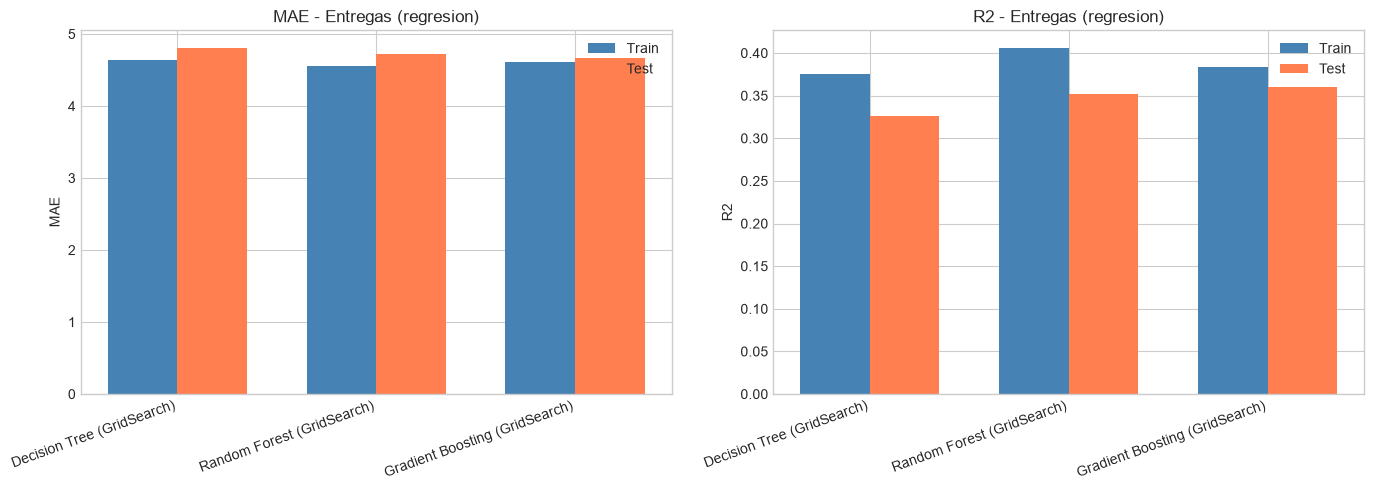

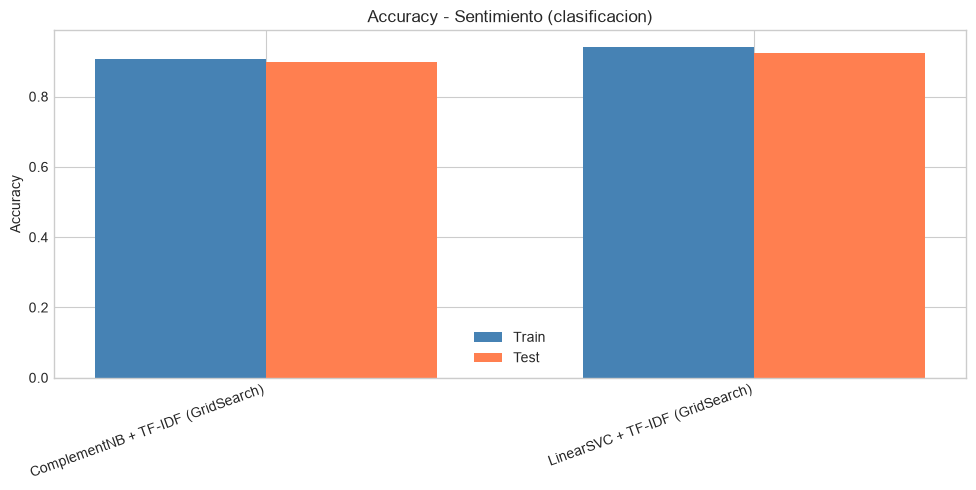

In [13]:
# Separa tablas por tipo de tarea
df_reg = df_comp[df_comp['task'] == 'regression']
df_cls = df_comp[df_comp['task'] == 'classification']

# bloque de regresion
if len(df_reg) > 0:
# 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# posiciones X
    x = np.arange(len(df_reg))
# ancho de barras
    w = 0.35
# MAE train
    axes[0].bar(x - w/2, df_reg['MAE_train'], w, label='Train', color='steelblue')
# MAE test
    axes[0].bar(x + w/2, df_reg['MAE_test'], w, label='Test', color='coral')
# etiqueta Y
    axes[0].set_ylabel('MAE')
# titulo
    axes[0].set_title('MAE - Entregas (regresion)')
# posiciona etiquetas
    axes[0].set_xticks(x)
# rota
    axes[0].set_xticklabels(df_reg['name'], rotation=20, ha='right')
# leyenda
    axes[0].legend()
# R2 train
    axes[1].bar(x - w/2, df_reg['R2_train'], w, label='Train', color='steelblue')
# R2 test
    axes[1].bar(x + w/2, df_reg['R2_test'], w, label='Test', color='coral')
# etiqueta Y
    axes[1].set_ylabel('R2')
# titulo
    axes[1].set_title('R2 - Entregas (regresion)')
# posiciona
    axes[1].set_xticks(x)
# rota
    axes[1].set_xticklabels(df_reg['name'], rotation=20, ha='right')
# leyenda
    axes[1].legend()
# ajusta
    plt.tight_layout()
# muestra
    plt.show()

# bloque de clasificacion
if len(df_cls) > 0:
# figura de un subplot
    fig, ax = plt.subplots(figsize=(10, 5))
# posiciones
    x = np.arange(len(df_cls))
# acc train
    ax.bar(x - w/2, df_cls['acc_train'], w, label='Train', color='steelblue')
# acc test
    ax.bar(x + w/2, df_cls['acc_test'], w, label='Test', color='coral')
# etiqueta Y
    ax.set_ylabel('Accuracy')
# titulo
    ax.set_title('Accuracy - Sentimiento (clasificacion)')
# posiciona
    ax.set_xticks(x)
# rota
    ax.set_xticklabels(df_cls['name'], rotation=20, ha='right')
# leyenda
    ax.legend()
# ajusta
    plt.tight_layout()
# muestra
    plt.show()